## Linear Classification:

So far we have been introduced to a supervised model called linear regression in which we had to predict a continuous real value based on some input features. In previous lesson we learned that we have bunch of parameters and a training procedure with a training set and a cost function which quantified how well our model was working and bunch of optimization methods that would optimize the parameters based on the value of the cost function and it's varialbes. In linear classification the routine is mostly the same but the methods and some concepts are going to change, let's start:

We are sometimes in some predicting scenarios that we're predicting from a finite descrete set, for example guessing a picture is a cat or not, we can set 1 for *is cat* and 0 for *is not cat* and these kind of problems. For these kind of questions we use a learning model called **Linear Classification** In which despite the previuos model we learned we are not trying to fit a line or a function to our data, instead we want to distinguish between our data and have a hyperplane to distinguish between different classes of our data best.

**Goal**: Given an input $X$, assign it to one one of **K** classes.
(e.g., Email Spam Detection, Medical Diagnosis, churn prediction, and etc).

### Discrimination Functions

Discrimination Function is a function that assings a score to an input vector $x$, to classify it into different classes.
It maps the input $x$ to a real number $g(x)$, which represents the degree of confidence in assigning $x$ to a particular class.

+ **Binary Classification**:

    Two functions $g_1(x)$ and $g_2(x)$ for classes $C_1$ and $C_2$, respectively. The class is predicted by comparing by computing these two functions:
    $$\hat{y}: If g_1(x) > g_2(x): C_1, otherwise: C_2$$

+ **General Case**:

    for *k-class* problems, we compute $g_i(x)$ for every class *i*, and assign *x* to class with highest score:
    $$
    \hat{y} = \arg\max_{i} \, g_i(x)
    $$

### Decision Boundry

A dividing hyperplane that separate different classes in a feature space, also known as "Decision surface":

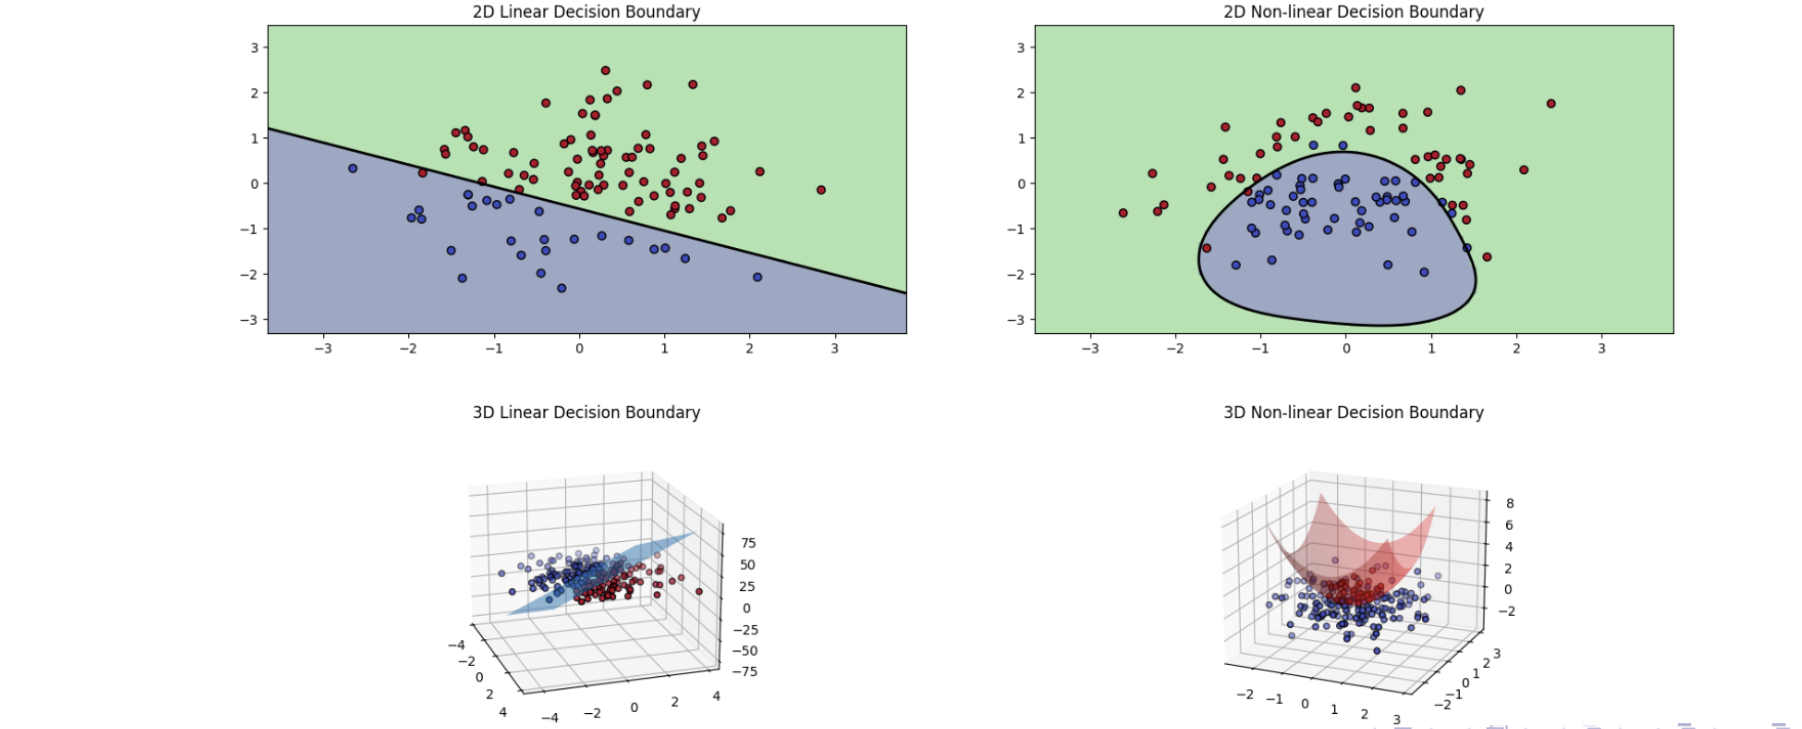

> As you can see in the figure above based on the samples that we've got, we have different models of decision boundry surface.

> If we've got a `D` dimensional environment of data we tend to divide between data using a `D-1` hyperplane

Now we wanna have a model to draw and result this decision boundry or decision surface for us.



### Linear Classifiers:

In case of linear classifiers, decision boundaries are linear in *d*, or linear in some given set of functions of *x*.

For a D dimensional features space we're gonna have a D-1 dimensional hyperplane separator:

$$\text{Decision Boundary} = w_0 + w_1.x^{(i)}_1 + w_2.x^{(i)}_2 + ... + w_d.x^{(i)}_d = 0$$

The equation above is the equation for the hyperplane for a **Two-Category** classification in a D dimension features space

Some times samples are separable linearly and sometimes not, for non-linear decision boundaires we tend to do things that make us able to find a hyperplane to separate: 

By `Feature Transformation` we be able to introduce non-linearity and transforming features into a higher dimensional space. And the decision boundary becomes linear in the new space, but non-linear in the original space:

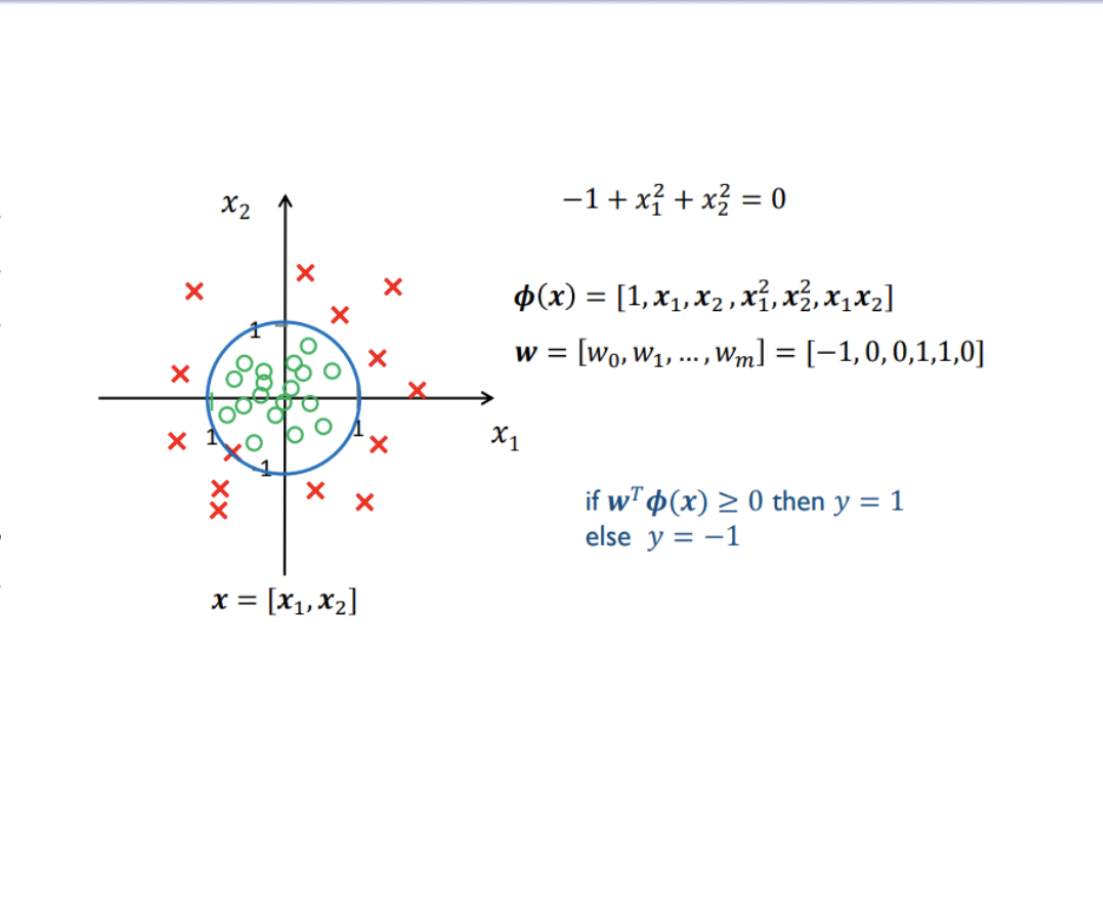


### Perceptron Unit:

It is a structure that models an artificial neuron, by mapping input features with a weight to an output by applying a linear combination and a threshold. The weighted sum of the inputs go through an activation function, which is an artificual modeling of the firing mechanism in neurons and set intervals for the output of the weighted sum of the inputs and using those intervals it assigns them to an appropriate class.

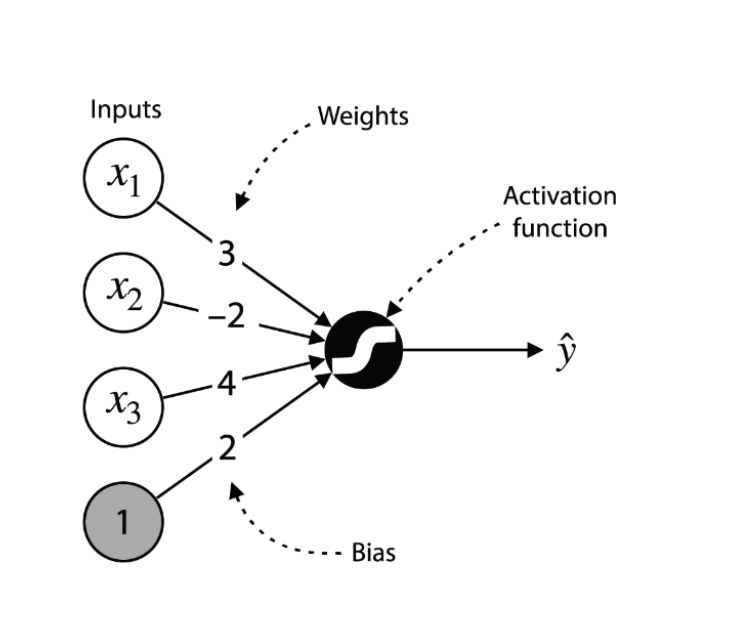


The goal in Linear Classification is to find the **hyperplane** (defined by **w** and bias **b**) such that:
$$f(x) = w^Tx + b$$
+ If $f(x) > 0 $, we classify it as class +1
+ If $f(x) < 0 $, we classify it as class -1


**How do we define this hyperplane?**

1. **Perceptron Algorithm** (for linear separable data):

    We iteratively adjusts the weights $w$ based on `misclassified` points. Updates:
    $$w := w + \eta . y^{(i)} . x^{(i)}$$
    Where $y^{(i)} \in \{-1, +1\}$

2. **Logistic Regression** (for probabilistic interpretation):

    Learns parameters by minimizing **log-loss** using **gradient descent**. 
    
    It uses the sigmoid function:
    $$\hat{y} = \sigma(w^Tx + b) = \frac{1}{1 + e^{-(w^Tx + b)}}$$
    Then it minimizes:
    $$Loss = -[y\log(\hat{y}) + (1- y)\log{(1 - \hat{y})}]$$

**Single neuron as a Linear Decision Boundary**

+ **Mathematical form**: The output of a signle neuron is computed as:
$$y = f(w^Tx + w_0)$$

+ **Linear separation**: A neuron defines a linear decision boundar:
$$w^Tx + w_0 = threshold \text{(0 for step, 0.5 for sigmoid)} $$



### Cost Function

+ Our goal in linear classification is to find optimal w so that predicted lables match the true labels as much as possible. And to achieve this we define a cost function, which measures the **difference** between **predicted** and **actual** labels.

Finding discriminant functions $(w^T, w_0)$ is framed as minimizing a cost function. Problem converts to finding optimal $\hat{g}(x) = g(x;\hat{w})$ where:

$$\hat{w} = \argmin_{w} J(w)$$

So far the cost function we have used was SSE but this cost function mimizes the magnitude of the error, which is ideal for regression and `irrelevant` for classification. SSE is also prone to overfitting noisy data, as small variations can cause significant changes in the cost.

There is an alternative for SSE const function:

> For using an SSE like cost function we use the step activation function for the perceptron as you can see in below:

**Number of Misclassifications**:

+ It measures how many samples are misclassified by the model

$$J(w) = \sum_{i=1}^{n} (\frac{y^{(i)} - sign(\hat{y}^{(i)})}{2})^2, \hat{y}^{(i)} = w^Tx^{(i)} +w_0, y^{(i)} \in \{-1, 1\}$$

> The cost function above is non-differentiable cause the $sign(\hat{y}^{(i)})$ is not differentiable, so optimization techniques (like GD) cannot be difrectly applied. We wan't to smooth the cost function's plot a bit so we be able to use optimization tools on it.

As we know the perceptron algorithm's purpose is it being a simple algorithm for binary classification, separating two classes with a linear boundry. 

So for this purpose and the problem that we had with the previous cost function we introduce another cost function which focuses only on misclassified points:

$$J_{p}(w) = - \sum_{i \in M} y^{(i)}w^Tx(i), y^{(i)} \in \{-1, +1\}$$

> Where M is the set of misclassified points.

And the goal of the cost function above is to minimize the loss by correctly classifying all points.

> This new cost function is differentiable and can uses optimization tools on it and in the below figure you can see a comparison between the two introduced cost function for perceptron so you be able to understand why we say the first one is non-differentiable and the second one is more smooth and differentiable

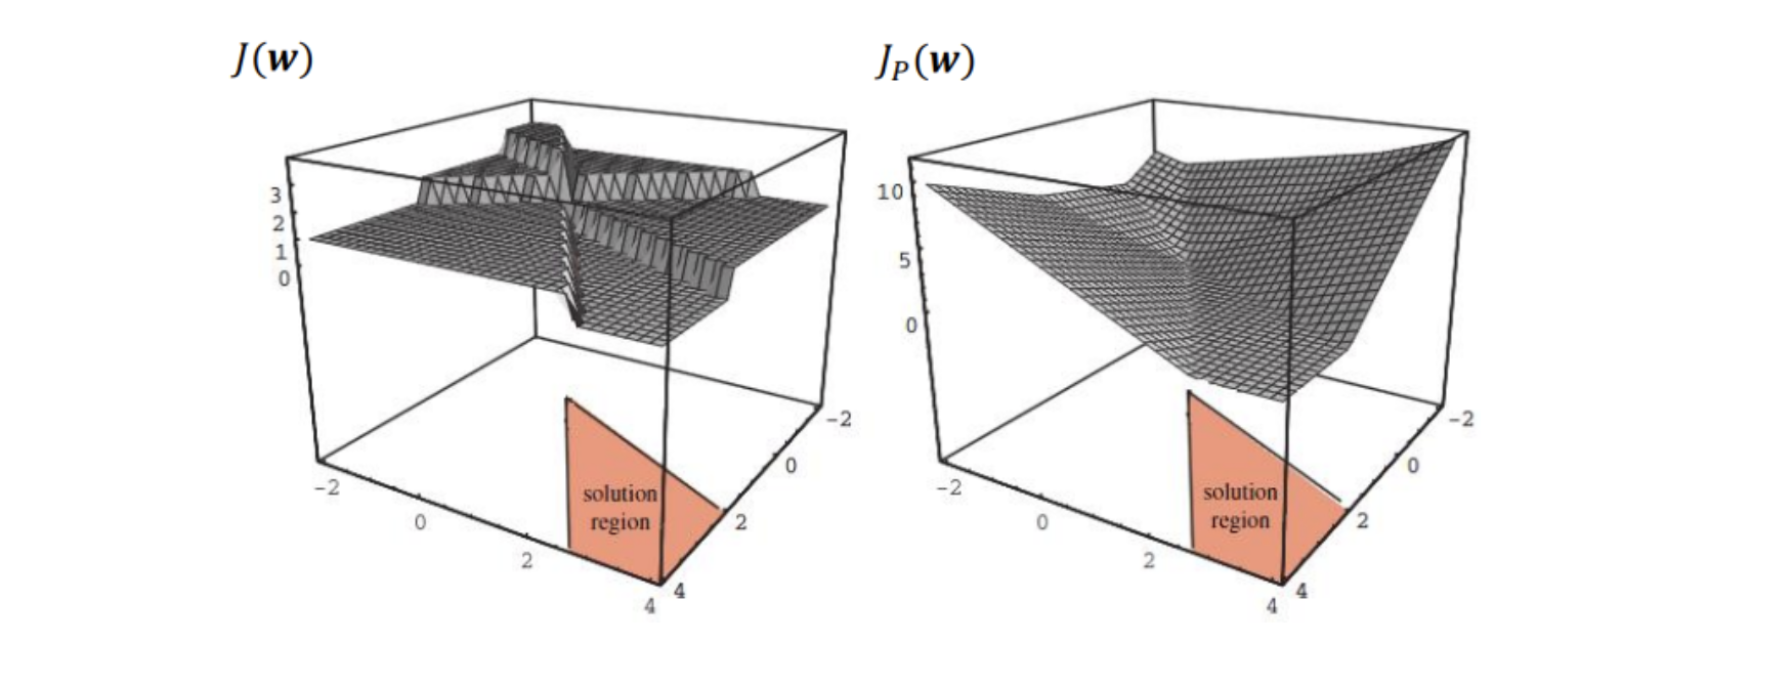

> The activation function in the second cost function is not directly used in the cost function but rahter it is used in the perceptron prediction and just checks if the prediction is the correct class or not and if not the point is added to the M set.


**Batch Perceptron**: Updates the weight vector using all misclassified points in each iteration.

> Let's dig into the difference between Batch perceptron and the **online(standard)** Perceptron:

+ **Online(Standard) Perceptron**:

    It processes **one training sample at a time** and updates weights **immediately** after each **misclassified** example:
    $$w := w + \eta . y^{(i)}. x^{(i)}$$
    $$b := b + \eta . y^{(i)}$$

    Because of this **immediate** behavior it's often called **online** or **incremental** learning.


+ **Batch Perceptron**:

    It still aims to find a linear hyperplane between two classes. But instead of updating weights after **each misclassified sample**, it goes through the **entire training dataset**, collects all the **misclassified points** in a batch, Then makes a **single cumulative udpdate** at the end of the pass.


    Algorithm steps:
    1. Initialize weights $w$, bias $b$
    2. Loop until convergence:
        1. Go through **all training example**
        2. **Identify misclassified samples** 
        3. Sum their contributions:
        $$\Delta{w} = \eta \sum_{\text{misclassified i}} y^{(i)} x^{(i)}$$
        $$\Delta{b} = \eta \sum_{\text{misclassified i}} y^{(i)}$$
        4. Update:
        $$w := w + \Delta{w}$$
        $$b := b + \Delta{b}$$


+ **When to use Batch Perceptron**: 

    When our data is small to medium and can fit in memory, and when we want more **stable convergence**, and when we want to exploit **vectorized operations**. 


**Stochastic Gradient Descent Updating rule**:

Instead of computing the gradient over all samples, it picks a **single (random) sample** at each step and updates weights. It is much faster per iteration and enables online or streaming training.

+ Using only one misclassified sample at a time:
$$w \leftarrow w + \eta w y_i x_i$$

+ Lower computational cost per iteration, faster convegence.
+ If training a data are linearly separable, the single-sample perceptron is also guaranteed to find a solution in a finite number of steps.


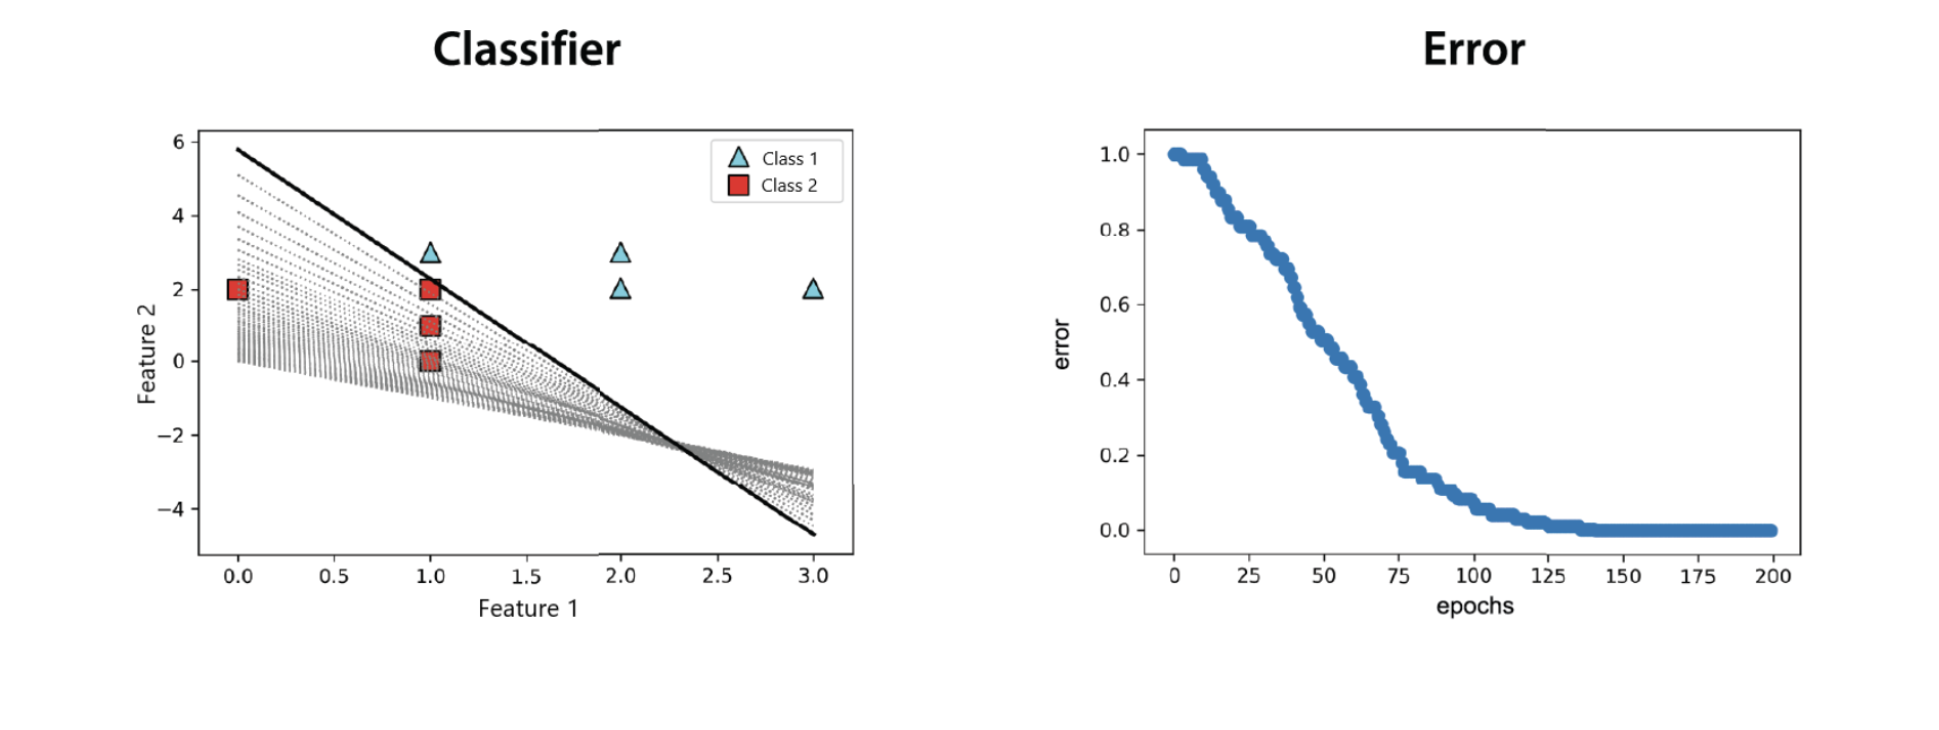

> The above figure also is showing what happens in iterations and in hyperplane update and the error reduction in iterations